# Customer Segmentation, Retention & Revenue Analysis for an Online Retailer
**Author:** Rishika Garg

## 1. Introduction
This project analyses the full UCI Online Retail transaction dataset for a UK-based online gift retailer. It identifies valuable customers, measures retention, models lapse risk, and recommends marketing actions. All reported figures are calculated from the transaction data.


## 2. Data Loading & Understanding

The analysis uses the full dataset without sampling. The source is the Kaggle copy of the UCI Online Retail dataset. Save it as data.csv in this folder. Kaggle: https://www.kaggle.com/datasets/carrie1/ecommerce-data. Original source: https://archive.ics.uci.edu/dataset/352/online+retail

### Data Dictionary
| Field | Type | Business meaning | Use |
|---|---|---|---|
| InvoiceNo | String | Transaction/invoice identifier; `C` prefix indicates cancellation | Invoice counts and cancellation flags |
| StockCode | String | Product or service code | Product analysis |
| Description | String | Product description | Product labels |
| Quantity | Integer | Units sold or returned | Revenue and cancellation screening |
| InvoiceDate | Datetime | Transaction timestamp | Time, RFM, retention, and lapse modelling |
| UnitPrice | Float | Price per unit in pounds | Revenue calculation |
| CustomerID | Float/string | Customer identifier; missing for guest transactions | Customer-level analysis |
| Country | String | Customer country | Geographic analysis |

Revenue is calculated as `Quantity × UnitPrice`. Customer identifiers are used for aggregation and are not printed in the notebook outputs.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
BASE = Path.cwd()
source = BASE / "data.csv"
if not source.exists():
    raise FileNotFoundError("Place data.csv beside this notebook; download it using the README instructions.")
raw = pd.read_csv(source, encoding="latin1")
print("Source:", source.name)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
print("Raw sample values are intentionally not printed because the file contains customer identifiers.")
print(raw.dtypes.to_string())


Source: data.csv
Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Raw sample values are intentionally not printed because the file contains customer identifiers.
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str


## 3. Data Cleaning & Data Scope
Revenue is Quantity × UnitPrice. Cancelled invoices (InvoiceNo starting with C or Quantity < 0), non-positive prices, non-product administrative codes, and exact duplicates are excluded from sales analysis. Customers without CustomerID are excluded from all customer-level analysis. December 2011 is treated as partial when its observed day coverage is much shorter than the complete prior month, and is excluded from monthly trend charts.


Cohort boundary note: December 2010 is a left-censored cohort because the data starts then, so those customers may pre-date the dataset. Corrected retention excludes December 2010 and excludes cohorts too recent to have the relevant month observed.

In [2]:
non_product = {"POST","D","M","DOT","BANK CHARGES","AMAZONFEE","CRUK","ADJUST","ADJUSTMENT","C2","B"}
def product_like(s): return ~s.astype(str).str.upper().isin(non_product) & ~s.astype(str).str.upper().str.match(r"^[A-Z]+$")
steps=[]
steps.append(("Raw rows", len(raw), len(raw)))
missing = raw["CustomerID"].isna(); steps.append(("Missing CustomerID removed", int(missing.sum()), len(raw)-int(missing.sum())))
work = raw[~missing].copy()
cancel = work["InvoiceNo"].astype(str).str.upper().str.startswith("C") | (work["Quantity"] < 0)
steps.append(("Cancellations removed", int(cancel.sum()), len(work)-int(cancel.sum())))
work = work[~cancel].copy()
price_bad = work["UnitPrice"] <= 0
steps.append(("Non-positive UnitPrice removed", int(price_bad.sum()), len(work)-int(price_bad.sum())))
work = work[~price_bad].copy()
nonprod = ~product_like(work["StockCode"])
steps.append(("Non-product StockCodes removed", int(nonprod.sum()), len(work)-int(nonprod.sum())))
work = work[~nonprod].copy()
before_dup=len(work); work=work.drop_duplicates(); steps.append(("Exact duplicates removed", before_dup-len(work), len(work)))
raw["InvoiceDate"]=pd.to_datetime(raw["InvoiceDate"], errors="coerce")
work["InvoiceDate"]=pd.to_datetime(work["InvoiceDate"], errors="coerce")
work["Revenue"]=work["Quantity"]*work["UnitPrice"]
complete_max = work["InvoiceDate"].dt.to_period("M").max()
month_orders=work.assign(month=work["InvoiceDate"].dt.to_period("M")).groupby("month")["InvoiceNo"].nunique()
last_month=month_orders.index.max(); prev_month=month_orders.index.max()-1
partial_month = month_orders[last_month] < 0.75*month_orders[prev_month]
complete_months = [x for x in month_orders.index if not (partial_month and x==last_month)]
known=raw[~raw["CustomerID"].isna()].copy(); known["Revenue"]=known["Quantity"]*known["UnitPrice"]; known_cancel=known["InvoiceNo"].astype(str).str.upper().str.startswith("C") | (known["Quantity"] < 0); valid_known=known[(known["UnitPrice"]>0) & product_like(known["StockCode"])]; cancel_valid=valid_known[known_cancel[valid_known.index]]; positive_valid=valid_known[~known_cancel[valid_known.index]]; cancel_invoice_rate=valid_known.loc[known_cancel[valid_known.index],"InvoiceNo"].nunique()/valid_known["InvoiceNo"].nunique(); cancel_line_rate=cancel_valid.shape[0]/valid_known.shape[0]; cancelled_revenue=abs(cancel_valid["Revenue"].sum()); gross_revenue=positive_valid["Revenue"].sum()+cancelled_revenue; cancel_revenue_rate=cancelled_revenue/gross_revenue; cancellation_metrics={"cancelled_invoices":int(valid_known.loc[known_cancel[valid_known.index],"InvoiceNo"].nunique()),"cancelled_line_items":int(cancel_valid.shape[0]),"cancelled_revenue_gbp":float(cancelled_revenue),"cancellation_invoice_rate":float(cancel_invoice_rate),"cancellation_line_item_rate":float(cancel_line_rate),"cancellation_revenue_rate":float(cancel_revenue_rate),"cancellation_rate_definition":"Cancelled invoices / invoices with known CustomerID; cancelled line items / line items with known CustomerID; absolute cancelled revenue / (positive sales + absolute cancelled revenue)."}; print(json.dumps(cancellation_metrics,indent=2)); print(pd.DataFrame(steps, columns=["Cleaning step","Rows removed","Rows remaining"]).to_string(index=False))
print("Analysis scope: positive, non-cancelled product sales with known CustomerID; final scope month excludes", last_month, "as partial." if partial_month else "no month excluded.")


{
  "cancelled_invoices": 3383,
  "cancelled_line_items": 8539,
  "cancelled_revenue_gbp": 474403.3300000001,
  "cancellation_invoice_rate": 0.1552903373881111,
  "cancellation_line_item_rate": 0.021090407927365416,
  "cancellation_revenue_rate": 0.051367535277289704,
  "cancellation_rate_definition": "Cancelled invoices / invoices with known CustomerID; cancelled line items / line items with known CustomerID; absolute cancelled revenue / (positive sales + absolute cancelled revenue)."
}
                 Cleaning step  Rows removed  Rows remaining
                      Raw rows        541909          541909
    Missing CustomerID removed        135080          406829
         Cancellations removed          8905          397924
Non-positive UnitPrice removed            40          397884
Non-product StockCodes removed          1547          396337
      Exact duplicates removed          5187          391150
Analysis scope: positive, non-cancelled product sales with known CustomerID; fin

## 4. Executive Overview (KPIs)
The following KPIs use the final sales scope. Net revenue excludes cancellations; cancellation rate is calculated on rows with known CustomerID.


In [3]:
sales=work.copy()
orders=sales["InvoiceNo"].nunique(); customers=sales["CustomerID"].nunique(); revenue=sales["Revenue"].sum()
invoice_orders=sales.groupby("InvoiceNo")["Revenue"].sum()
aov=invoice_orders.mean(); freq=sales.groupby("CustomerID")["InvoiceNo"].nunique()
repeat_rate=(freq>=2).mean(); cancel_rate=cancel.sum()/ (~missing).sum(); uk_share=sales.loc[sales["Country"].eq("United Kingdom"),"Revenue"].sum()/revenue
kpis={"net_revenue_gbp":float(revenue),"orders":int(orders),"customers":int(customers),"average_order_value_gbp":float(aov),"average_orders_per_customer":float(freq.mean()),"repeat_customer_rate":float(repeat_rate),"cancellation_rate":float(cancel_rate),"cancelled_invoices":cancellation_metrics["cancelled_invoices"],"cancelled_line_items":cancellation_metrics["cancelled_line_items"],"cancellation_invoice_rate":cancellation_metrics["cancellation_invoice_rate"],"cancellation_line_item_rate":cancellation_metrics["cancellation_line_item_rate"],"cancelled_revenue_gbp":cancellation_metrics["cancelled_revenue_gbp"],"cancellation_revenue_rate":cancellation_metrics["cancellation_revenue_rate"],"uk_revenue_share":float(uk_share),"analysis_start":str(sales["InvoiceDate"].min()),"analysis_end":str(sales["InvoiceDate"].max()),"complete_months":[str(x) for x in complete_months]}
print(json.dumps(kpis, indent=2))


{
  "net_revenue_gbp": 8737227.64,
  "orders": 18402,
  "customers": 4334,
  "average_order_value_gbp": 474.79771981306385,
  "average_orders_per_customer": 4.2459621596677435,
  "repeat_customer_rate": 0.6527457314259345,
  "cancellation_rate": 0.021888803403887137,
  "cancelled_invoices": 3383,
  "cancelled_line_items": 8539,
  "cancellation_invoice_rate": 0.1552903373881111,
  "cancellation_line_item_rate": 0.021090407927365416,
  "cancelled_revenue_gbp": 474403.3300000001,
  "cancellation_revenue_rate": 0.051367535277289704,
  "uk_revenue_share": 0.8289649324050345,
  "analysis_start": "2010-12-01 08:26:00",
  "analysis_end": "2011-12-09 12:50:00",
  "complete_months": [
    "2010-12",
    "2011-01",
    "2011-02",
    "2011-03",
    "2011-04",
    "2011-05",
    "2011-06",
    "2011-07",
    "2011-08",
    "2011-09",
    "2011-10",
    "2011-11"
  ]
}


## 5. Sales & Product Analysis
Revenue is analysed by complete month, weekday, hour, product, and country. Product Pareto uses distinct StockCodes. Country AOV is shown only for countries with at least 10 orders.


Top non-UK country concentration:
             Customers    Revenue  LargestCustomerShare
Country                                                
Netherlands          9 283,889.34                  0.98
EIRE                 3 257,013.12                  0.53
Germany             94 205,381.15                  0.08
France              87 183,801.94                  0.10
Australia            9 138,103.81                  0.90
Spain               30  55,706.56                  0.22
Switzerland         21  52,441.95                  0.21
Japan                8  37,416.37                  0.57
Belgium             25  36,927.34                  0.13
Sweden               8  36,828.83                  0.86
{
  "peak_month": "2011-11",
  "peak_month_revenue": 1136534.0,
  "q4_share_complete_month_revenue": 0.328761126401811,
  "average_month_revenue": 685416.63,
  "peak_uplift_vs_average": 0.6581651950872567
}


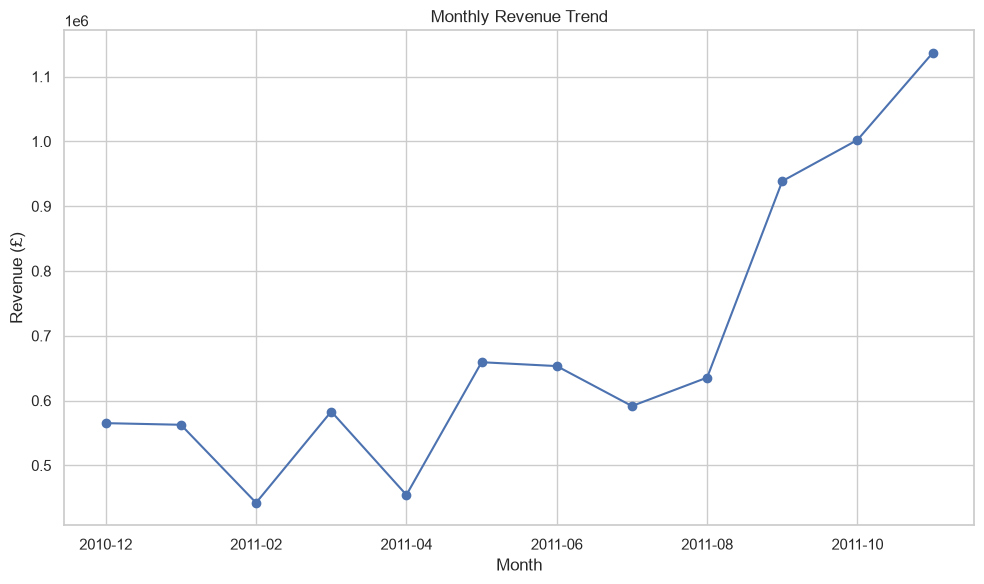

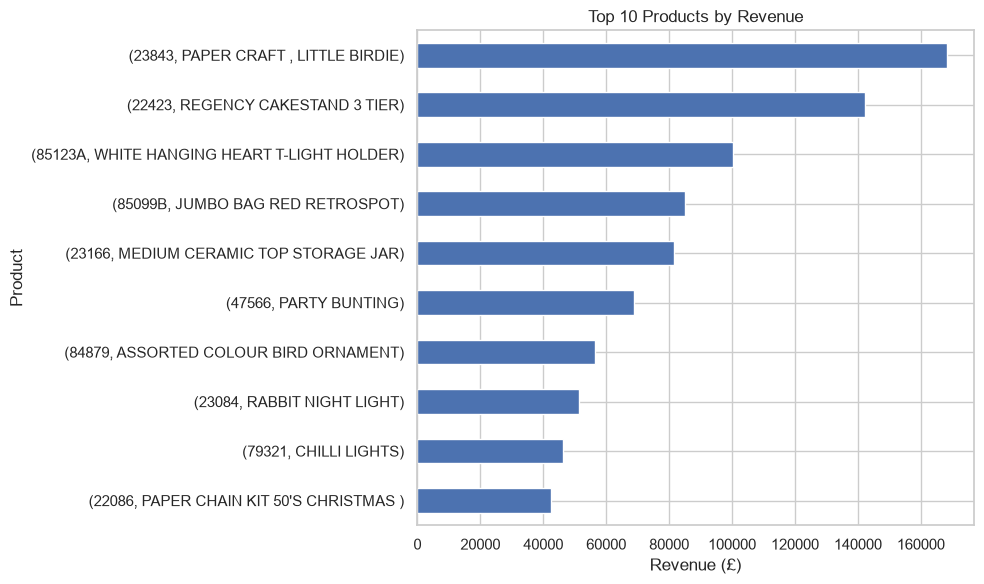

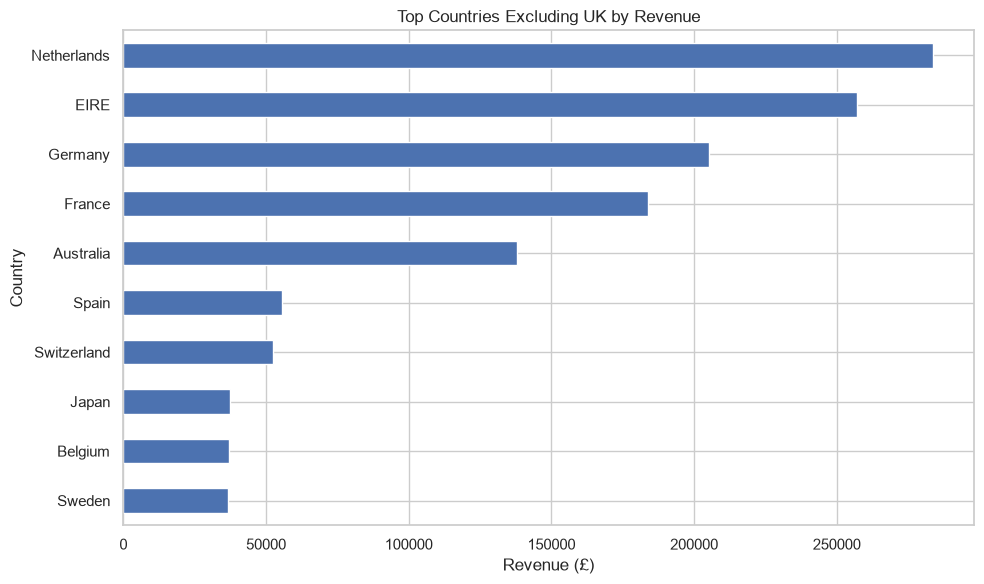

In [4]:
sales["Month"]=sales["InvoiceDate"].dt.to_period("M").astype(str); sales["Weekday"]=sales["InvoiceDate"].dt.day_name(); sales["Hour"]=sales["InvoiceDate"].dt.hour
monthly=sales[sales["Month"].isin([str(x) for x in complete_months])].groupby("Month")["Revenue"].sum()
weekday=sales.groupby("Weekday")["Revenue"].sum().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
hourly=sales.groupby("Hour")["Revenue"].sum()
product=sales.groupby(["StockCode","Description"], dropna=False)["Revenue"].sum().sort_values(ascending=False)
top_product=product.head(10); product_pareto=product.cumsum()/product.sum(); product_pareto_value=float(product_pareto.iloc[max(0, int(np.ceil(len(product)*.2))-1)])
country=sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False); non_uk=country[country.index!="United Kingdom"].head(10)
country_orders=sales.groupby("Country")["InvoiceNo"].nunique(); country_revenue=sales.groupby("Country")["Revenue"].sum(); eligible=country_orders[country_orders>=10].index; country_aov=pd.DataFrame({"Revenue":country_revenue.reindex(eligible),"Orders":country_orders.reindex(eligible)}).assign(AOV=lambda x:x["Revenue"]/x["Orders"]).sort_values("AOV",ascending=False); customer_country=sales.groupby(["Country","CustomerID"])["Revenue"].sum(); country_detail=pd.DataFrame({"Customers":sales.groupby("Country")["CustomerID"].nunique(),"Revenue":country_revenue,"LargestCustomerShare":customer_country.groupby(level=0).max()/country_revenue}).loc[non_uk.index]; print("Top non-UK country concentration:"); print(country_detail.round(4).to_string()); seasonality_monthly=monthly; peak_month=seasonality_monthly.idxmax(); q4_revenue=seasonality_monthly[seasonality_monthly.index.str[-2:].isin(["10","11","12"])].sum(); seasonality_metrics={"peak_month":str(peak_month),"peak_month_revenue":float(seasonality_monthly.loc[peak_month]),"q4_share_complete_month_revenue":float(q4_revenue/seasonality_monthly.sum()),"average_month_revenue":float(seasonality_monthly.mean()),"peak_uplift_vs_average":float(seasonality_monthly.loc[peak_month]/seasonality_monthly.mean()-1)}; print(json.dumps(seasonality_metrics,indent=2));
fig,ax=plt.subplots(figsize=(10,6)); monthly.plot(kind="line",marker="o",ax=ax); ax.set(title="Monthly Revenue Trend",xlabel="Month",ylabel="Revenue (£)"); fig.tight_layout(); fig.savefig(BASE/"monthly_revenue_trend.png",dpi=110); plt.show()
fig,ax=plt.subplots(figsize=(10,6)); top_product.plot(kind="barh",ax=ax); ax.invert_yaxis(); ax.set(title="Top 10 Products by Revenue",xlabel="Revenue (£)",ylabel="Product"); fig.tight_layout(); fig.savefig(BASE/"top_products.png",dpi=110); plt.show()
fig,ax=plt.subplots(figsize=(10,6)); non_uk.sort_values().plot(kind="barh",ax=ax); ax.set(title="Top Countries Excluding UK by Revenue",xlabel="Revenue (£)",ylabel="Country"); fig.tight_layout(); fig.savefig(BASE/"country_revenue.png",dpi=110); plt.show()


## 6. Customer Segmentation (RFM)
RFM is calculated per CustomerID. Recency is measured from the day after the last transaction. Quintile scores use rank method to handle ties. Transparent segment rules are applied to the R/F/M scores.


                     Customers      Revenue  AvgRecency  AvgFrequency  AvgMonetary  AvgAOV  RevenueShare
Segment                                                                                                 
Champions                  941 5,660,267.34       12.99         11.13     6,015.16   36.10          0.65
Loyal                      770 1,379,043.58       35.61          4.12     1,790.97   99.40          0.16
Hibernating               1077   515,665.77      217.65          1.10       478.80  112.49          0.06
Can't Lose Them            179   430,884.31      123.12          5.39     2,407.17   64.36          0.05
At Risk                    478   381,755.17      161.41          2.66       798.65   57.91          0.04
Potential Loyalists        347   162,988.77       53.19          1.14       469.71   23.10          0.02
New                        310   133,025.33       18.71          1.24       429.11   39.09          0.02
Lost                       232    73,597.37       28.16

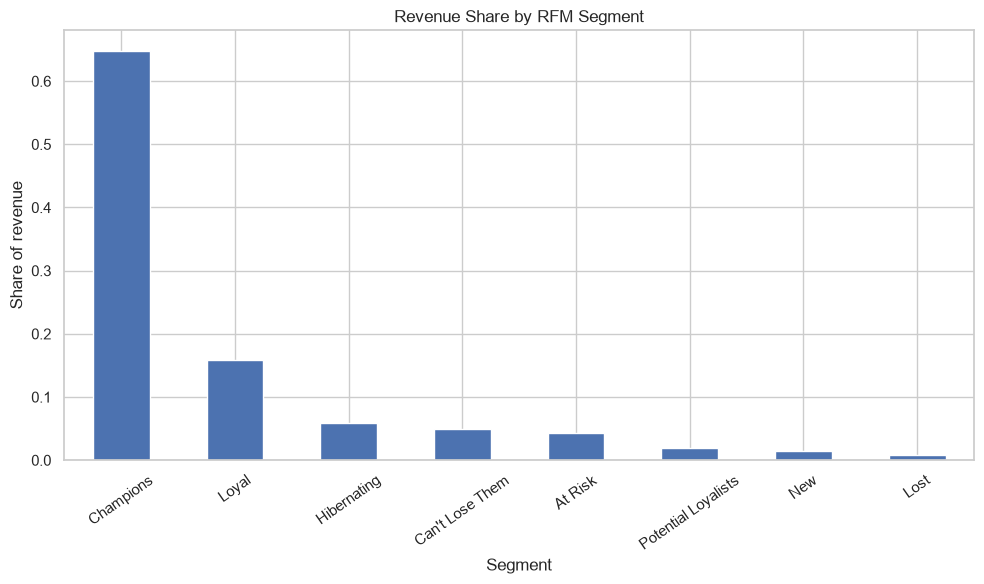

In [5]:
last_day=sales["InvoiceDate"].max().normalize()+pd.Timedelta(days=1)
rfm=sales.groupby("CustomerID").agg(Recency=("InvoiceDate",lambda x:(last_day-x.max().normalize()).days),Frequency=("InvoiceNo","nunique"),Monetary=("Revenue","sum"),AOV=("Revenue",lambda x:x.sum()/x.count() if x.count() else 0),Tenure=("InvoiceDate",lambda x:(x.max().normalize()-x.min().normalize()).days+1),DistinctProducts=("StockCode","nunique"),Country=("Country",lambda x:x.mode().iloc[0] if not x.mode().empty else ""))
rfm["R"]=pd.qcut(rfm["Recency"].rank(method="first"),5,labels=[5,4,3,2,1]).astype(int); rfm["F"]=pd.qcut(rfm["Frequency"].rank(method="first"),5,labels=[1,2,3,4,5]).astype(int); rfm["M"]=pd.qcut(rfm["Monetary"].rank(method="first"),5,labels=[1,2,3,4,5]).astype(int)
def seg(x):
    if x.R>=4 and x.F>=4 and x.M>=4:return "Champions"
    if x.R>=3 and x.F>=3 and x.M>=3:return "Loyal"
    if x.R>=4 and x.F<=2:return "New"
    if x.R==3 and x.F<=2:return "Potential Loyalists"
    if x.R<=2 and x.F>=4 and x.M>=4:return "Can't Lose Them"
    if x.R<=2 and x.F>=3:return "At Risk"
    if x.R<=2 and x.F<=2:return "Hibernating"
    return "Lost"
rfm["Segment"]=rfm.apply(seg,axis=1)
seg_table=rfm.groupby("Segment").agg(Customers=("Segment","size"),Revenue=("Monetary","sum"),AvgRecency=("Recency","mean"),AvgFrequency=("Frequency","mean"),AvgMonetary=("Monetary","mean"),AvgAOV=("AOV","mean")).sort_values("Revenue",ascending=False); seg_table["RevenueShare"]=seg_table.Revenue/seg_table.Revenue.sum()
sorted_monetary=rfm.sort_values("Monetary",ascending=False).Monetary; top10_customer_revenue_share=float(sorted_monetary.head(10).sum()/sorted_monetary.sum()); top50_customer_revenue_share=float(sorted_monetary.head(50).sum()/sorted_monetary.sum()); champions=rfm[rfm["Segment"]=="Champions"].sort_values("Monetary",ascending=False); top10_champions_revenue_share=float(champions.head(10).Monetary.sum()/champions.Monetary.sum()) if len(champions) else 0.0; customer_pareto=sorted_monetary.cumsum()/sorted_monetary.sum(); customer_pareto_value=float(customer_pareto.iloc[max(0,int(np.ceil(len(rfm)*.2))-1)])
print(seg_table.to_string()); print(f"Top 20% product revenue share: {product_pareto_value:.4f}"); print(f"Top 20% customer revenue share: {customer_pareto_value:.4f}"); print(f"Top 10 customers revenue share: {top10_customer_revenue_share:.4f}"); print(f"Top 50 customers revenue share: {top50_customer_revenue_share:.4f}"); print(f"Top 10 Champions revenue share: {top10_champions_revenue_share:.4f}")
fig,ax=plt.subplots(figsize=(10,6)); seg_table["RevenueShare"].plot(kind="bar",ax=ax); ax.set(title="Revenue Share by RFM Segment",xlabel="Segment",ylabel="Share of revenue"); ax.tick_params(axis="x",rotation=35); fig.tight_layout(); fig.savefig(BASE/"segment_revenue_share.png",dpi=110); plt.show()


## 7. Retention
Repeat-customer rate is the share of customers with at least two distinct positive-sales invoices. Month-1 retention is the share of acquisition-cohort customers who buy again in the next month; month-3 retention uses the third month after acquisition. A monthly acquisition cohort is defined by a customer's first purchase month. Retention is the share of cohort customers with a purchase in each subsequent month. Month-1 and month-3 retention are averaged across eligible cohorts.


Retention here is the share of a cohort buying in that specific month, not a running total. Many customers skip a month or two and return later, so the share buying in month 3 can be higher than in month 1; the pattern varies by cohort.

Uncorrected retention: {'month_1': 0.18857064090698203, 'month_3': 0.17890150565894616}
Corrected retention (excludes Dec 2010 and immature cohorts): {'month_1': 0.1974578608047018, 'month_3': 0.22856537951105407, 'eligible_cohorts_month_1': ['2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10'], 'eligible_cohorts_month_3': ['2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08']}
Age       0    1    2    3    4    5    6    7    8    9    10   11   12
Cohort                                                                  
2010-12 1.00 0.36 0.32 0.38 0.36 0.40 0.36 0.35 0.35 0.40 0.37 0.50 0.27
2011-01 1.00 0.22 0.27 0.23 0.32 0.29 0.25 0.24 0.30 0.33 0.36 0.12 0.00
2011-02 1.00 0.19 0.19 0.29 0.27 0.24 0.26 0.27 0.25 0.30 0.07 0.00 0.00
2011-03 1.00 0.15 0.25 0.20 0.22 0.17 0.27 0.23 0.28 0.09 0.00 0.00 0.00
2011-04 1.00 0.21 0.20 0.21 0.20 0.23 0.22 0.26 0.07 0.00 0.00 0.00 0.00
2011-05 1.00 0.19

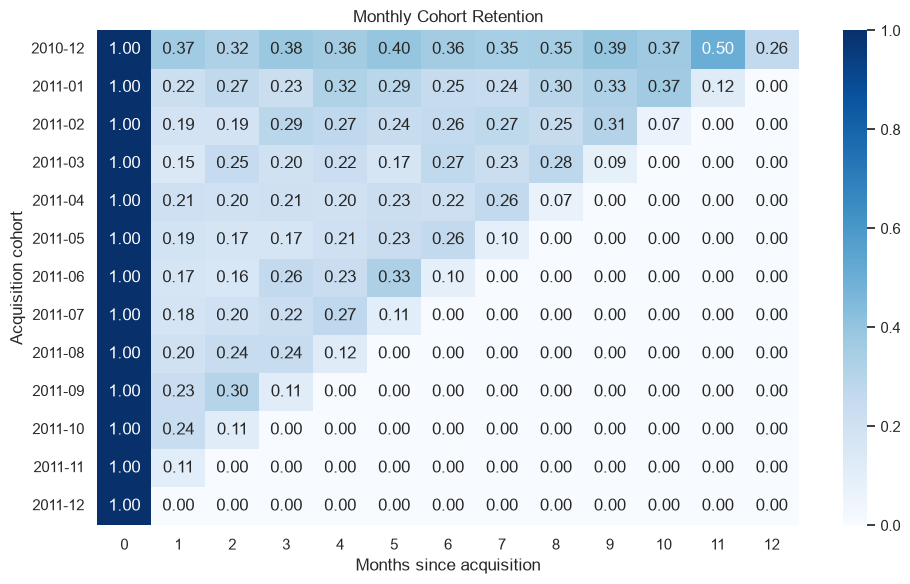

In [6]:
sales["MonthPeriod"]=sales["InvoiceDate"].dt.to_period("M"); first=sales.groupby("CustomerID")["MonthPeriod"].min(); sales["Cohort"]=sales["CustomerID"].map(first); sales["Age"]=(sales["MonthPeriod"]-sales["Cohort"]).apply(lambda x:x.n)
cohort_counts=sales.groupby("Cohort")["CustomerID"].nunique().rename("CohortCustomers"); retention=sales.groupby(["Cohort","Age"])["CustomerID"].nunique().unstack(fill_value=0); retention=retention.div(cohort_counts,axis=0).fillna(0); last_complete_month=pd.Period(sorted(complete_months)[-1],freq="M"); uncorrected={"month_1":float(retention.get(1,pd.Series(dtype=float)).mean()),"month_3":float(retention.get(3,pd.Series(dtype=float)).mean())}; eligible1=[cohort for cohort in retention.index if cohort!=pd.Period("2010-12",freq="M") and cohort+1<=last_complete_month]; eligible3=[cohort for cohort in retention.index if cohort!=pd.Period("2010-12",freq="M") and cohort+3<=last_complete_month]; corrected={"month_1":float(retention.loc[eligible1,1].mean()),"month_3":float(retention.loc[eligible3,3].mean()),"eligible_cohorts_month_1":[str(x) for x in eligible1],"eligible_cohorts_month_3":[str(x) for x in eligible3]}; month1=corrected["month_1"]; month3=corrected["month_3"]; print("Uncorrected retention:",uncorrected); print("Corrected retention (excludes Dec 2010 and immature cohorts):",corrected); print(retention.round(3).to_string())
fig,ax=plt.subplots(figsize=(10,6)); sns.heatmap(retention,annot=True,fmt=".2f",cmap="Blues",ax=ax); ax.set(title="Monthly Cohort Retention",xlabel="Months since acquisition",ylabel="Acquisition cohort"); fig.tight_layout(); fig.savefig(BASE/"cohort_retention_heatmap.png",dpi=110); plt.show()

## 8. Predictive Model - customer lapse
The cutoff is approximately three months before the last complete month. Features use only transactions before cutoff. The label is whether a customer has no purchase in the following 90 days. The model is compared with a majority baseline and a recency rule.


              Model  Accuracy  Precision  Recall   F1  ROC_AUC
Logistic Regression      0.70       0.67    0.75 0.71     0.76
  Majority baseline      0.51       0.00    0.00 0.00     0.50
 Recency >= 90 days      0.66       0.69    0.57 0.62     0.69
Continuous recency ROC-AUC is 0.686; Logistic Regression adds 0.073 ROC-AUC. This is a modest, real gain; use the simple recency rule when simplicity matters.


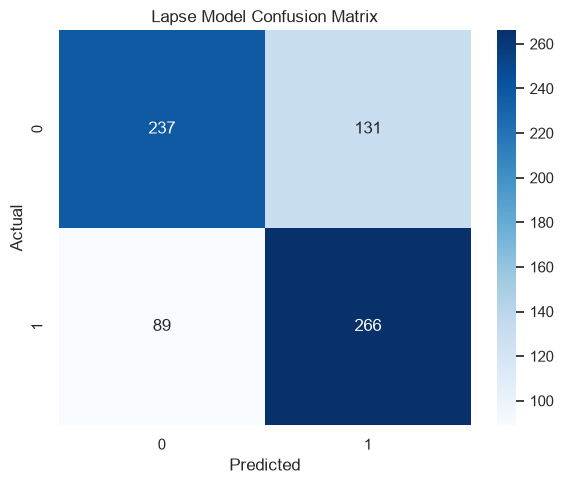

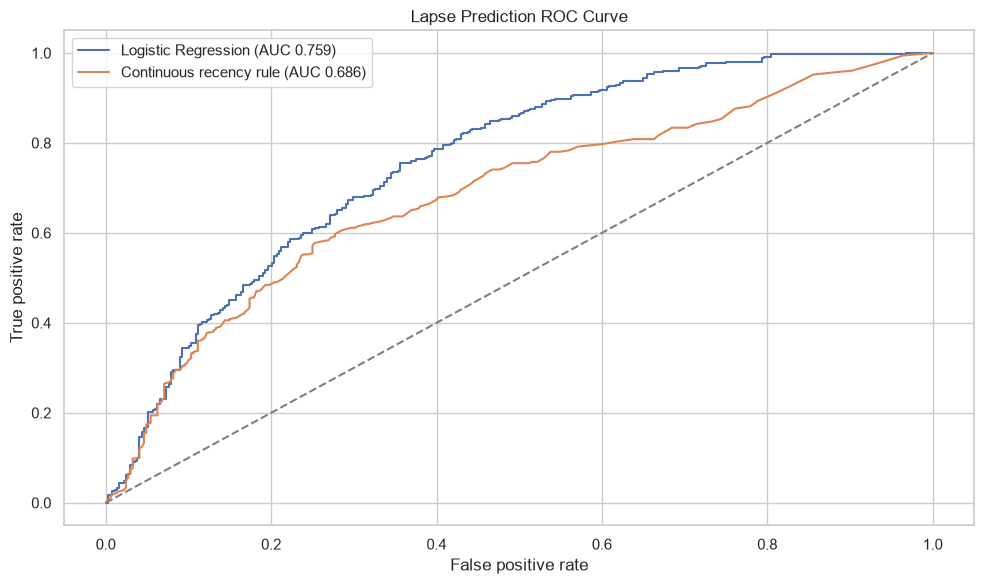

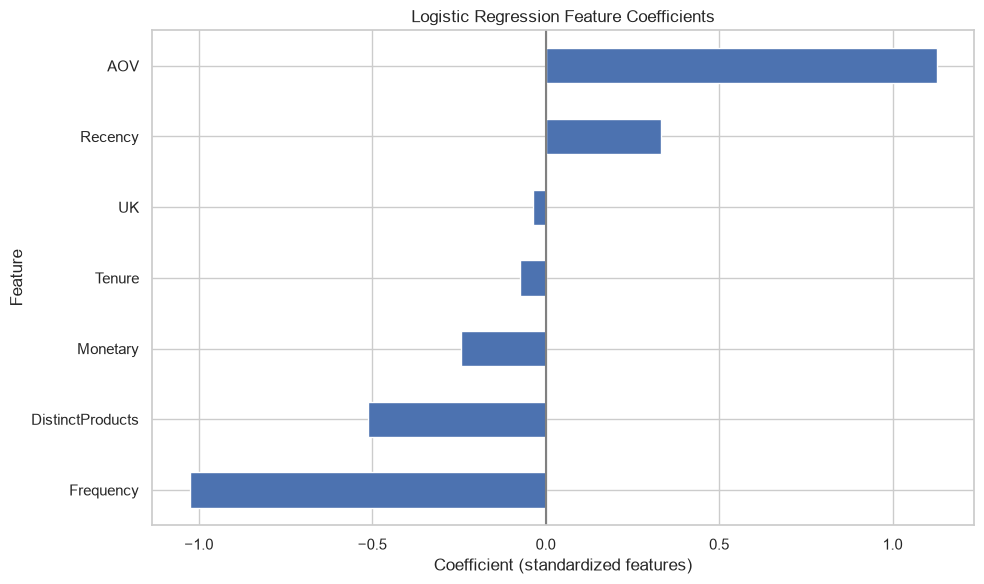

  tier  Customers  HistoricalRevenue  RevenueShare
   Low       1106       4,607,640.08          0.76
Medium       1514       1,006,746.05          0.17
  High        993         471,752.87          0.08
Model evaluation used the held-out test set; risk tiers were assigned by scoring all eligible pre-cutoff customers.


In [7]:
cutoff=(sales["MonthPeriod"].max()-2).start_time
pre=sales[sales["InvoiceDate"]<cutoff]; post=sales[(sales["InvoiceDate"]>=cutoff)&(sales["InvoiceDate"]<cutoff+pd.Timedelta(days=90))]
feat=pre.groupby("CustomerID").agg(Recency=("InvoiceDate",lambda x:(cutoff-x.max().normalize()).days),Frequency=("InvoiceNo","nunique"),Monetary=("Revenue","sum"),AOV=("Revenue",lambda x:x.sum()/x.count()),Tenure=("InvoiceDate",lambda x:(cutoff-x.min().normalize()).days+1),DistinctProducts=("StockCode","nunique"),UK=("Country",lambda x:float((x=="United Kingdom").any())))
feat["label"]=(~feat.index.isin(post["CustomerID"].unique())).astype(int)
X=feat[["Recency","Frequency","Monetary","AOV","Tenure","DistinctProducts","UK"]]; y=feat["label"]; Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,stratify=y,random_state=42)
model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000,random_state=42)).fit(Xtr,ytr); pred=model.predict(Xte); prob=model.predict_proba(Xte)[:,1]
rec=(feat.loc[Xte.index,"Recency"]); rec_score=(rec>=90).astype(int)
rows=[]
for name,yp,sp in [("Logistic Regression",pred,prob),("Majority baseline",np.repeat(ytr.mode()[0],len(yte)),np.repeat(ytr.mode()[0],len(yte))),("Recency >= 90 days",rec_score,rec)]:
    rows.append({"Model":name,"Accuracy":accuracy_score(yte,yp),"Precision":precision_score(yte,yp,zero_division=0),"Recall":recall_score(yte,yp,zero_division=0),"F1":f1_score(yte,yp,zero_division=0),"ROC_AUC":roc_auc_score(yte,sp) if len(np.unique(yte))>1 else np.nan})
model_table=pd.DataFrame(rows); print(model_table.round(3).to_string(index=False)); auc_gain=model_table.loc[model_table.Model=="Logistic Regression","ROC_AUC"].iloc[0]-model_table.loc[model_table.Model=="Recency >= 90 days","ROC_AUC"].iloc[0]; model_interpretation=f"Continuous recency ROC-AUC is {model_table.loc[model_table.Model=='Recency >= 90 days','ROC_AUC'].iloc[0]:.3f}; Logistic Regression adds {auc_gain:.3f} ROC-AUC. This is a modest, real gain; use the simple recency rule when simplicity matters."; print(model_interpretation)
cm=confusion_matrix(yte,pred); fig,ax=plt.subplots(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=ax); ax.set(title="Lapse Model Confusion Matrix",xlabel="Predicted",ylabel="Actual"); fig.tight_layout(); fig.savefig(BASE/"lapse_confusion_matrix.png",dpi=110); plt.show()
fig,ax=plt.subplots(figsize=(10,6));
for label,score in [("Logistic Regression",prob),("Continuous recency rule",rec)]:
    fpr,tpr,_=roc_curve(yte,score); ax.plot(fpr,tpr,label=f"{label} (AUC {roc_auc_score(yte,score):.3f})")
ax.plot([0,1],[0,1],"--",color="grey"); ax.set(title="Lapse Prediction ROC Curve",xlabel="False positive rate",ylabel="True positive rate"); ax.legend(); fig.tight_layout(); fig.savefig(BASE/"lapse_roc_curve.png",dpi=110); plt.show()
coef=pd.Series(model[-1].coef_[0],index=X.columns).sort_values(); fig,ax=plt.subplots(figsize=(10,6)); coef.plot(kind="barh",ax=ax); ax.axvline(0,color="grey"); ax.set(title="Logistic Regression Feature Coefficients",xlabel="Coefficient (standardized features)",ylabel="Feature"); fig.tight_layout(); fig.savefig(BASE/"lapse_feature_coefficients.png",dpi=110); plt.show()
risk=pd.DataFrame({"CustomerID":feat.index,"probability":model.predict_proba(feat[X.columns])[:,1]}).set_index("CustomerID"); risk["tier"]=pd.cut(risk.probability,[-np.inf,.4,.65,np.inf],labels=["Low","Medium","High"]); risk["historical_revenue"]=feat["Monetary"]; risk_table=risk.groupby("tier",observed=False).agg(Customers=("tier","size"),HistoricalRevenue=("historical_revenue","sum")).reset_index(); risk_table["RevenueShare"]=risk_table.HistoricalRevenue/risk_table.HistoricalRevenue.sum(); print(risk_table.to_string(index=False)); print("Model evaluation used the held-out test set; risk tiers were assigned by scoring all eligible pre-cutoff customers.")


## 9. Business Insights
The five findings below are selected from computed segment, revenue, retention, and model results. Each action is tied to an observed number.


In [8]:
# Five computed findings, ranked by business impact.
topseg=seg_table.index[0]; high=risk_table.loc[risk_table.tier=="High"].iloc[0]; month1_text=f"{month1:.1%}"; month3_text=f"{month3:.1%}"; concentration_text=f"Top 10 customers contribute {top10_customer_revenue_share:.1%} of revenue, top 50 contribute {top50_customer_revenue_share:.1%}, and the top 10 Champions contribute {top10_champions_revenue_share:.1%} of Champions revenue."; champions_count=int(seg_table.loc[topseg,"Customers"]); champions_customer_share=champions_count/len(rfm); country_detail_sorted=country_detail.sort_values("Revenue",ascending=False); country_quote=", ".join(f"{name}: {int(row.Customers)} customers, largest customer {row.LargestCustomerShare:.1%}" for name,row in country_detail_sorted.loc[["Netherlands","EIRE","Australia","Sweden","Germany","France"]].iterrows());
insights=[
 {"rank":1,"observation":f"{champions_count} {topseg} customers are {champions_customer_share:.1%} of all customers and bring in {seg_table.loc[topseg,'RevenueShare']:.1%} of revenue. {concentration_text}","insight":"A small number of customers drive most sales.","risk_opportunity":"Losing a few large customers would reduce revenue.","action":"Manage the top wholesale accounts separately with key-account service, and use mass-market loyalty offers for the broader customer base."},
 {"rank":2,"observation":f"After excluding Dec 2010 and immature cohorts, {month1_text} of acquired customers buy again in month 1; month 3 is {month3_text}. Retention here is the share of a cohort buying in that specific month, not a running total. Many customers skip a month or two and return later, so the share buying in month 3 can be higher than in month 1; the pattern varies by cohort.","insight":"Most customers do not return soon after their first purchase.","risk_opportunity":"The retailer is losing early repeat-purchase opportunities.","action":"Send a second-purchase offer within 30 days and time reminder campaigns to customers' typical reorder gap (months 2-3), not only a 30-day offer."},
 {"rank":3,"observation":f"{int(high.Customers)} High-risk customers account for {high.RevenueShare:.1%} of historical revenue.","insight":"Some customers at risk of lapsing have already spent significantly.","risk_opportunity":"A win-back campaign can protect revenue at risk.","action":"Contact High-risk customers with a relevant offer and a service check."},
 {"rank":4,"observation":f"Most non-UK revenue depends on a few wholesale accounts: {country_quote}.","insight":"Germany and France are the only broad-based overseas markets in this table because their largest customers contribute only 8.5% and 10.2% of country revenue.","risk_opportunity":"Country totals can overstate broad demand when a few wholesale buyers dominate.","action":"Manage the large overseas buyers as key accounts, and target Germany and France for customer acquisition."},
 {"rank":5,"observation":f"Revenue peaks in {seasonality_metrics['peak_month']} at £{seasonality_metrics['peak_month_revenue']:,.2f}, {seasonality_metrics['peak_uplift_vs_average']:.1%} above the complete-month average; complete-month Q4 revenue is {seasonality_metrics['q4_share_complete_month_revenue']:.1%} of annual revenue.","insight":"Demand is strongest in the final quarter.","risk_opportunity":"Campaigns started too late will miss the highest-revenue period.","action":"Plan and launch Q4 campaigns early, with inventory and delivery capacity prepared in advance."}
]
print(json.dumps(insights,indent=2))

[
  {
    "rank": 1,
    "observation": "941 Champions customers are 21.7% of all customers and bring in 64.8% of revenue. Top 10 customers contribute 17.4% of revenue, top 50 contribute 33.4%, and the top 10 Champions contribute 24.6% of Champions revenue.",
    "insight": "A small number of customers drive most sales.",
    "risk_opportunity": "Losing a few large customers would reduce revenue.",
    "action": "Manage the top wholesale accounts separately with key-account service, and use mass-market loyalty offers for the broader customer base."
  },
  {
    "rank": 2,
    "observation": "After excluding Dec 2010 and immature cohorts, 19.7% of acquired customers buy again in month 1; month 3 is 22.9%. Retention here is the share of a cohort buying in that specific month, not a running total. Many customers skip a month or two and return later, so the share buying in month 3 can be higher than in month 1; the pattern varies by cohort.",
    "insight": "Most customers do not return so

## 10. Conclusion, Limitations, Future Scope
The project provides a complete descriptive, RFM, retention, and leakage-safe lapse analysis. Limitations include retailer-specific transaction context, lack of margin and marketing-cost data, partial final month, and observational (not causal) model findings. Future work can add profit, campaign, seasonality, and time-based validation features, and test interventions through controlled experiments.


In [9]:
seg_json=seg_table.reset_index().round(6).to_dict(orient="records"); model_json=model_table.round(6).to_dict(orient="records"); risk_json=risk_table.round(6).to_dict(orient="records")
output={"kpis":kpis,"segment_table":seg_json,"model_vs_baselines":model_json,"risk_tiers":risk_json,"product_top_20_share":product_pareto_value,"customer_top_20_share":customer_pareto_value,"retention":{"month_1":month1,"month_3":month3,"uncorrected_month_1":uncorrected["month_1"],"uncorrected_month_3":uncorrected["month_3"],"eligible_cohorts_month_1":corrected["eligible_cohorts_month_1"],"eligible_cohorts_month_3":corrected["eligible_cohorts_month_3"]},"customer_concentration":{"top_10_revenue_share":top10_customer_revenue_share,"top_50_revenue_share":top50_customer_revenue_share,"top_10_champions_revenue_share":top10_champions_revenue_share},"cancellation_metrics":cancellation_metrics,"country_concentration":country_detail.reset_index().round(6).to_dict(orient="records"),"seasonality":seasonality_metrics,"model_interpretation":model_interpretation}
(BASE/"kpis.json").write_text(json.dumps(output,indent=2),encoding="utf-8"); (BASE/"insights.json").write_text(json.dumps(insights,indent=2),encoding="utf-8")
print("Wrote kpis.json and insights.json")


Wrote kpis.json and insights.json
